Loading datasets...
Data merged. We have 25 common years to analyze.
Fitting quadratic model (Yield = B0 + B1*Rain + B2*Rain^2)...
Model fitting complete.

--- MODEL RESULTS ---
  Intercept (B0): -1.4572064593
  Rainfall (B1):   0.0044523692
  Rainfall^2 (B2): -0.0000016989
  Rainfall^2 (B2) (scientific): -1.698934e-06
  R-squared:       0.7484176941

Plotting results...


C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


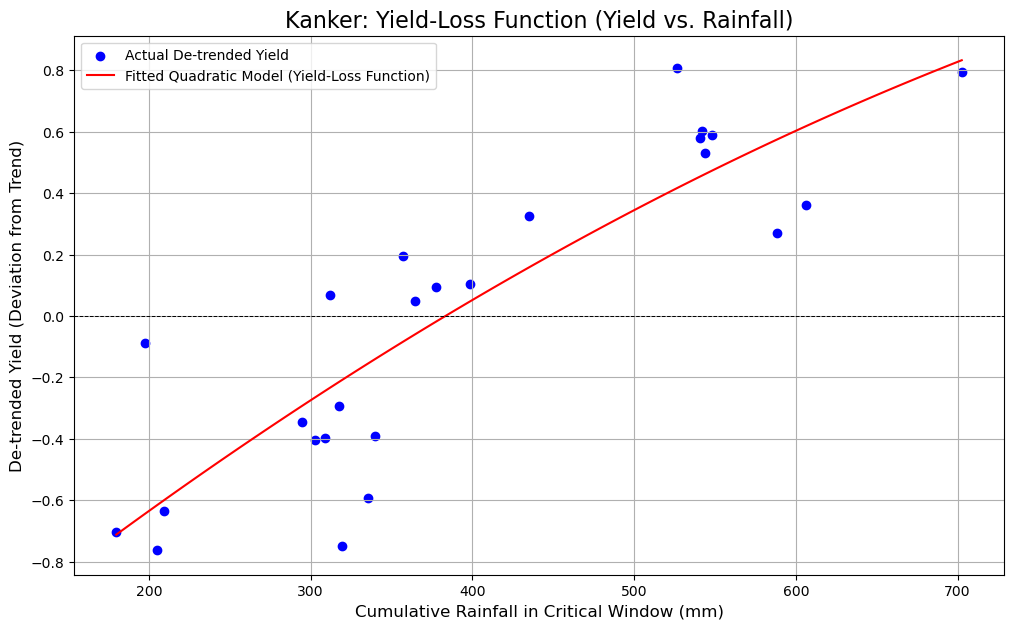

In [1]:
    # -------------------------------------------------------------------
# CHAPTER 3.4.2: HEDGE JUSTIFICATION (YIELD-LOSS FUNCTION)
# -------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# --- 1. Define File Names ---
FINAL_INDEX_FILE = 'final_index_series.csv'
YIELD_FILE_DETRENDED = 'kanker_yield_detrended.csv'

print("Loading datasets...")
try:
        index_df = pd.read_csv(FINAL_INDEX_FILE)
        yield_df = pd.read_csv(YIELD_FILE_DETRENDED)
except FileNotFoundError as e:
        print(f"--- ERROR: {e} ---")
        print("Make sure both 'final_index_series.csv' and 'kanker_yield_detrended.csv' are in your folder.")

# --- 2. Merge Data ---
# Combine the two files on 'Year' to get X and y in one place
merged_df = pd.merge(index_df, yield_df, on='Year')

# Define our X and y
X = merged_df[['Index_Value_mm']] # Needs to be a 2D array for sklearn
y = merged_df['Yield_Detrended']

print(f"Data merged. We have {len(merged_df)} common years to analyze.")

# --- 3. Fit the Quadratic Model ---
print("Fitting quadratic model (Yield = B0 + B1*Rain + B2*Rain^2)...")

# Create the polynomial features (X and X^2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Fit the linear regression model to these new features
model = LinearRegression()
model.fit(X_poly, y)

# Get the coefficients
# model.intercept_ is B0
# model.coef_[0] is B1 (the linear term)
# model.coef_[1] is B2 (the quadratic term)
B0 = model.intercept_
B1 = model.coef_[0]
B2 = model.coef_[1]

# Get the R-squared of this model
y_pred = model.predict(X_poly)
r_squared = r2_score(y, y_pred)

print("Model fitting complete.")

# --- 4. Print the Results ---
print("\n--- MODEL RESULTS ---")
print(f"  Intercept (B0): {B0:.10f}")
print(f"  Rainfall (B1):   {B1:.10f}")
print(f"  Rainfall^2 (B2): {B2:.10f}")
print(f"  Rainfall^2 (B2) (scientific): {B2:e}") # This will show the true value clearly
print(f"  R-squared:       {r_squared:.10f}")

# --- 5. Plot the Results ---
# 
print("\nPlotting results...")
plt.figure(figsize=(12, 7))

# Plot the original data points
plt.scatter(X, y, color='blue', label='Actual De-trended Yield')

# Create a smooth line for the fitted curve
X_fit = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_fit_poly = poly.transform(X_fit)
y_fit = model.predict(X_fit_poly)

# Plot the fitted quadratic curve
plt.plot(X_fit, y_fit, color='red', label='Fitted Quadratic Model (Yield-Loss Function)')

plt.title('Kanker: Yield-Loss Function (Yield vs. Rainfall)', fontsize=16)
plt.xlabel('Cumulative Rainfall in Critical Window (mm)', fontsize=12)
plt.ylabel('De-trended Yield (Deviation from Trend)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=0.7)
plt.legend()
plt.grid(True)
plt.savefig('Yield_Loss_Function_plot_1.png', bbox_inches='tight')
plt.show()